# 📊 소득 세그먼트 기반 고객 이탈 분석 (Income Segmentation & Churn Risk Analysis)

> **ChurnGuard 프로젝트** · 2주차 · 세그멘테이션 분석 노트북  
> 캘리포니아 센서스 소득 데이터가 병합된 `telco_churn_with_income.csv`를 사용합니다.

---

## 목차
1. 환경 설정 & 데이터 로드
2. 소득 세그먼트별 기본 통계 및 이탈률 분석
3. K-Means 기반 심층 군집화
4. 시각화 (Visualization)
5. 비즈니스 인사이트 & 리텐션 전략 제안

---
## 1. 환경 설정 & 데이터 로드

In [58]:
# ──────────────────────────────────────────────────
# 1-0. 라이브러리 임포트 & 한글 폰트 설정
# ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ── 한글 폰트 설정 (macOS: AppleGothic, Windows: Malgun Gothic) ──
import platform
if platform.system() == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

# ── Seaborn 스타일 ──
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print('✅ 환경 설정 완료')

✅ 환경 설정 완료


In [59]:
# ──────────────────────────────────────────────────
# 1-1. 데이터 로드 및 기본 전처리
# ──────────────────────────────────────────────────
DATA_PATH = '../data/telco_churn_with_income.csv'

df = pd.read_csv(DATA_PATH)

# Total Charges: str → float 변환 (공백 값 → NaN → 0 처리)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)

# Area_Income_Level 순서 지정 (Low < Medium < High < Very High)
INCOME_ORDER = ['Low', 'Medium', 'High', 'Very High']
df['Area_Income_Level'] = pd.Categorical(
    df['Area_Income_Level'], categories=INCOME_ORDER, ordered=True
)

print(f'✅ 데이터 로드 완료: {df.shape[0]:,}행 × {df.shape[1]}열')
print(f'   이탈 고객 수: {df["Churn Value"].sum():,}명  |  전체 이탈률: {df["Churn Value"].mean():.2%}')
print(f'\n   소득 세그먼트 분포:')
print(df['Area_Income_Level'].value_counts().sort_index().to_string())

✅ 데이터 로드 완료: 7,043행 × 40열
   이탈 고객 수: 1,869명  |  전체 이탈률: 26.54%

   소득 세그먼트 분포:
Area_Income_Level
Low          1621
Medium       1621
High         1616
Very High    1617


In [60]:
# ── 소득 파생 변수 7개 확인 ──
income_vars = ['Area_Total_Households', 'Area_Median_Income', 'Area_Mean_Income',
               'Income_Charge_Ratio', 'Area_Income_Level', 'Area_Low_Income_Ratio', 'Area_High_Income_Ratio']
df[income_vars].head()


,Area_Total_Households,Area_Median_Income,Area_Mean_Income,Income_Charge_Ratio,Area_Income_Level,Area_Low_Income_Ratio,Area_High_Income_Ratio
0,17782.0,56030.0,70030.0,0.011533,Low,32.3,22.9
1,18289.0,49419.0,83299.0,0.017167,Low,36.2,25.5
2,19709.0,51998.0,69243.0,0.022997,Low,33.8,19.6
3,2696.0,101455.0,132434.0,0.012396,High,17.3,51.2
4,13366.0,69268.0,106533.0,0.017965,Low,31.9,38.2


---
## 2. 소득 세그먼트별 기본 통계 및 이탈률 분석

`Area_Income_Level` (Low / Medium / High / Very High) 기준으로 그룹화하여 각 세그먼트의 핵심 지표를 비교합니다.

In [61]:
# ──────────────────────────────────────────────────
# 2-1. 소득 세그먼트별 핵심 지표 요약 테이블
# ──────────────────────────────────────────────────
segment_summary = df.groupby('Area_Income_Level', observed=False).agg(
    고객수          = ('Churn Value', 'count'),
    이탈고객수       = ('Churn Value', 'sum'),
    평균이탈률       = ('Churn Value', 'mean'),
    평균가입기간_월   = ('Tenure Months', 'mean'),
    월평균요금       = ('Monthly Charges', 'mean'),
    평균총요금       = ('Total Charges', 'mean'),
    평균중위소득     = ('Area_Median_Income', 'mean'),
    평균소득대비요금비율 = ('Income_Charge_Ratio', 'mean'),
).round(4)

segment_summary['이탈률(%)'] = (segment_summary['평균이탈률'] * 100).round(2)

print('\n📋 소득 세그먼트별 핵심 지표 요약')
print('=' * 90)
segment_summary


📋 소득 세그먼트별 핵심 지표 요약


,고객수,이탈고객수,평균이탈률,평균가입기간_월,월평균요금,평균총요금,평균중위소득,평균소득대비요금비율,이탈률(%)
Area_Income_Level,,,,,,,,,
Low,1621,446,0.2751,31.6841,64.5982,2243.4192,55459.5225,0.0148,27.51
Medium,1621,432,0.2665,32.7693,64.8517,2315.5009,81113.0716,0.0097,26.65
High,1616,432,0.2673,32.0829,65.0933,2276.4305,105195.8880,0.0075,26.73
Very High,1617,425,0.2628,32.6215,64.2193,2246.8335,155700.2839,0.0051,26.28


In [62]:
# ──────────────────────────────────────────────────
# 2-2. 세그먼트별 이탈률 vs 전체 이탈률 비교
# ──────────────────────────────────────────────────
overall_churn_rate = df['Churn Value'].mean()

print(f'▶ 전체 평균 이탈률: {overall_churn_rate:.2%}')
print(f'▶ 세그먼트별 이탈률 vs 전체 평균 대비 차이:\n')

for level in INCOME_ORDER:
    seg_rate = segment_summary.loc[level, '평균이탈률']
    diff = seg_rate - overall_churn_rate
    arrow = '🔴 ▲' if diff > 0 else '🟢 ▼'
    print(f'  {level:>10}:  {seg_rate:.2%}  ({arrow} {abs(diff):.2%}p)')

▶ 전체 평균 이탈률: 26.54%
▶ 세그먼트별 이탈률 vs 전체 평균 대비 차이:

         Low:  27.51%  (🔴 ▲ 0.97%p)
      Medium:  26.65%  (🔴 ▲ 0.11%p)
        High:  26.73%  (🔴 ▲ 0.19%p)
   Very High:  26.28%  (🟢 ▼ 0.26%p)


In [63]:
# ──────────────────────────────────────────────────
# 2-3. 소득 세그먼트 × 계약유형 교차 이탈률
#       (이탈 위험이 소득+계약에 의해 교차로 증폭되는지 확인)
# ──────────────────────────────────────────────────
cross_churn = df.groupby(
    ['Area_Income_Level', 'Contract'], observed=False
)['Churn Value'].agg(['mean', 'count']).rename(
    columns={'mean': '이탈률', 'count': '고객수'}
).round(4)

cross_churn['이탈률(%)'] = (cross_churn['이탈률'] * 100).round(2)

print('\n📋 소득 세그먼트 × 계약유형 교차 이탈률')
print('=' * 60)
cross_churn


📋 소득 세그먼트 × 계약유형 교차 이탈률


이탈률  고객수  이탈률(%)
Area_Income_Level Contract                           
Low               Month-to-month  0.4441  903   44.41
                  One year        0.1118  340   11.18
                  Two year        0.0185  378    1.85
Medium            Month-to-month  0.4322  870   43.22
                  One year        0.1163  344   11.63
                  Two year        0.0393  407    3.93
High              Month-to-month  0.4239  920   42.39
                  One year        0.1051  314   10.51
                  Two year        0.0236  382    2.36
Very High         Month-to-month  0.4237  878   42.37
                  One year        0.1098  346   10.98
                  Two year        0.0382  393    3.82

---
## 2-4. 통계적 가설 검증 (Statistical Testing)

핵심 가설: **"저소득 지역 고객은 동일 요금에서도 이탈 확률이 높을 것이다 (요금 민감도가 높다)"**

이를 검증하기 위해 두 가지 분석을 수행합니다.
1. **T-test**: 이탈 고객과 유지 고객 간 `Income_Charge_Ratio`(소득 대비 요금 부담률)의 평균 차이 검증
2. **상관관계 분석 (Correlation)**: 소득 수준 지표들과 이탈 여부 간의 관계


In [64]:
# ──────────────────────────────────────────────────
# 2-4-1. T-test: 이탈 여부에 따른 Income_Charge_Ratio 차이
# ──────────────────────────────────────────────────
from scipy import stats

churned = df[df['Churn Value'] == 1]['Income_Charge_Ratio'].dropna()
retained = df[df['Churn Value'] == 0]['Income_Charge_Ratio'].dropna()

t_stat, p_val = stats.ttest_ind(churned, retained, equal_var=False)

print(f"이탈 고객 평균 Income_Charge_Ratio: {churned.mean():.4f}")
print(f"유지 고객 평균 Income_Charge_Ratio: {retained.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")

if p_val < 0.05:
    print("✅ 결론: 이탈 고객과 유지 고객 간 통신비 부담률은 통계적으로 유의미한 차이가 있습니다.")
else:
    print("❌ 결론: 유의미한 차이가 없습니다.")


이탈 고객 평균 Income_Charge_Ratio: 0.0108
유지 고객 평균 Income_Charge_Ratio: 0.0087
T-statistic: 11.7208, p-value: 4.7677e-31
✅ 결론: 이탈 고객과 유지 고객 간 통신비 부담률은 통계적으로 유의미한 차이가 있습니다.


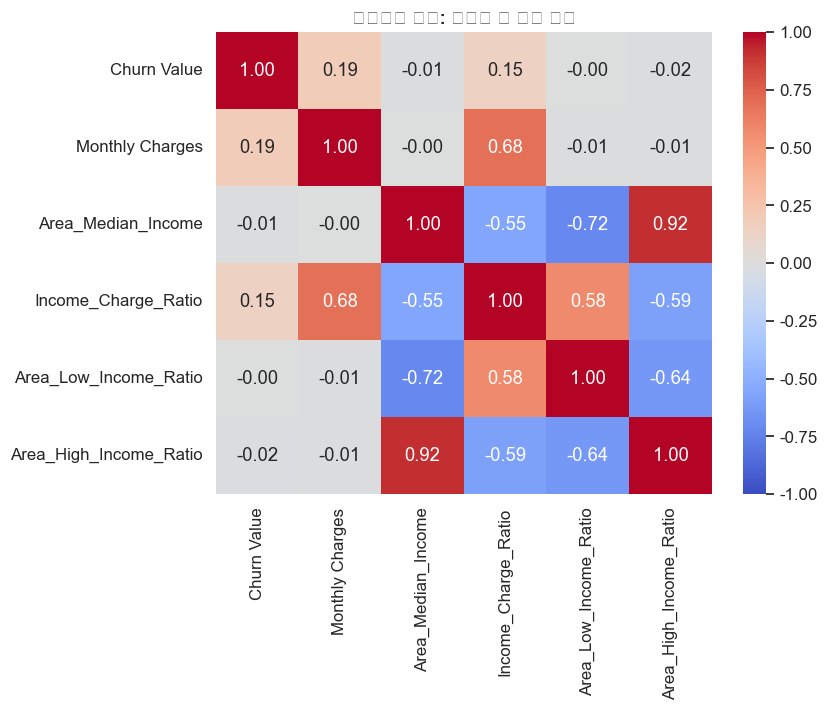

In [65]:
# ──────────────────────────────────────────────────
# 2-4-2. 상관관계 히트맵 (Correlation Heatmap)
# ──────────────────────────────────────────────────
corr_cols = ['Churn Value', 'Monthly Charges', 'Area_Median_Income', 
             'Income_Charge_Ratio', 'Area_Low_Income_Ratio', 'Area_High_Income_Ratio']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('상관관계 분석: 이탈률 및 주요 변수', fontweight='bold')
plt.show()


---
## 3. K-Means 기반 심층 군집화

소득 구간 범주화(Low~Very High) 외에, 연속형 변수 **Area_Median_Income · Total Charges · Tenure Months**를 결합하여 K-Means 클러스터링을 수행합니다.  
기존 소득 범주와 K-Means 군집 간의 이탈률 차이를 비교합니다.

In [66]:
# ──────────────────────────────────────────────────
# 3-1. K-Means 클러스터링 변수 선정 및 스케일링
# ──────────────────────────────────────────────────
CLUSTER_FEATURES = ['Area_Median_Income', 'Total Charges', 'Tenure Months', 'Income_Charge_Ratio', 'Area_Low_Income_Ratio']

X_cluster = df[CLUSTER_FEATURES].copy().dropna()
cluster_indices = X_cluster.index

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


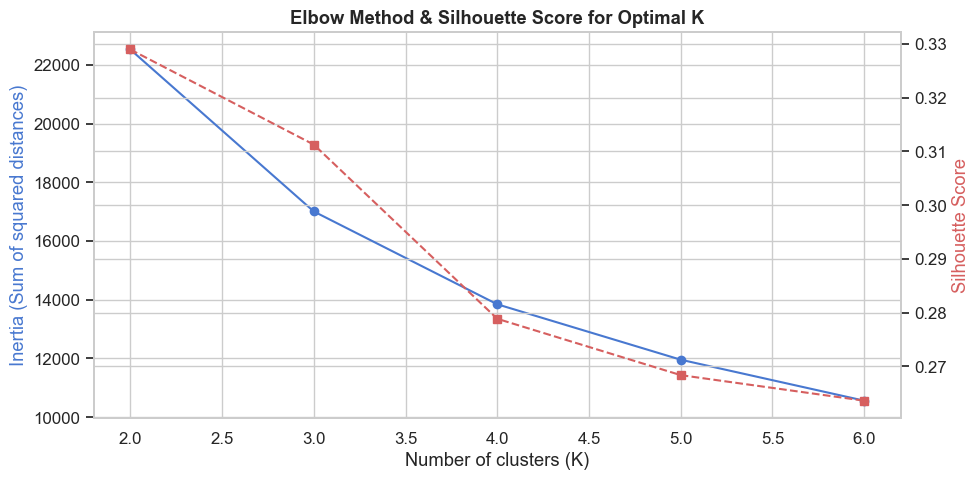

In [67]:
# ──────────────────────────────────────────────────
# 3-2. 엘보우 메서드 & 실루엣 스코어 (최적 K 탐색)
# ──────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    # 데이터 크기를 고려해 실루엣 스코어는 샘플링하여 계산
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=3000, random_state=42))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(K_range, inertias, 'bo-', label='Inertia')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia (Sum of squared distances)', color='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouettes, 'rs--', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Elbow Method & Silhouette Score for Optimal K', fontweight='bold')
fig.tight_layout()
plt.show()

# 시각화 결과 K=4 가 적절해 보임
OPTIMAL_K = 4
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df.loc[cluster_indices, 'KMeans_Cluster'] = km_final.fit_predict(X_scaled)


In [68]:
# ──────────────────────────────────────────────────
# 3-3. K-Means 군집별 프로파일 요약
# ──────────────────────────────────────────────────
cluster_profile = df.groupby('KMeans_Cluster').agg(
    고객수          = ('Churn Value', 'count'),
    이탈률          = ('Churn Value', 'mean'),
    평균가입기간     = ('Tenure Months', 'mean'),
    월평균요금       = ('Monthly Charges', 'mean'),
    평균총요금       = ('Total Charges', 'mean'),
    평균중위소득     = ('Area_Median_Income', 'mean'),
    평균소득대비요금비율 = ('Income_Charge_Ratio', 'mean'),
).round(4)

cluster_profile['이탈률(%)'] = (cluster_profile['이탈률'] * 100).round(2)

# 이탈률 내림차순 정렬 → 위험 군집 식별
cluster_profile = cluster_profile.sort_values('이탈률', ascending=False)

print('\n📋 K-Means 군집별 프로파일 (이탈률 높은 순)')
print('=' * 90)
cluster_profile


📋 K-Means 군집별 프로파일 (이탈률 높은 순)


,고객수,이탈률,평균가입기간,월평균요금,평균총요금,평균중위소득,평균소득대비요금비율,이탈률(%)
KMeans_Cluster,,,,,,,,
1.0,2351,0.3535,16.0561,55.2039,795.5597,77106.1982,0.0087,35.35
3.0,591,0.2809,42.8866,84.7201,3661.7680,48328.9171,0.0220,28.09
0.0,1813,0.2802,23.5648,51.4905,1090.8458,141375.6222,0.0045,28.02
2.0,1720,0.1337,60.0331,84.6891,5052.1405,102904.0837,0.0106,13.37


In [69]:
# ──────────────────────────────────────────────────
# 3-4. 소득 범주 vs K-Means 군집 교차표 (이탈률)
# ──────────────────────────────────────────────────
cross_tab = pd.crosstab(
    df['Area_Income_Level'],
    df['KMeans_Cluster'],
    values=df['Churn Value'],
    aggfunc='mean'
).round(4) * 100

print('\n📋 소득 범주(행) × K-Means 군집(열) 이탈률(%) 교차표')
print('=' * 60)
cross_tab.round(2)


📋 소득 범주(행) × K-Means 군집(열) 이탈률(%) 교차표


KMeans_Cluster,0.0,1.0,2.0,3.0
Area_Income_Level,,,,
Low,NaN,30.27,11.43,28.28
Medium,24.24,34.54,13.61,0.00
High,24.69,45.88,12.26,NaN
Very High,29.68,40.00,15.48,NaN


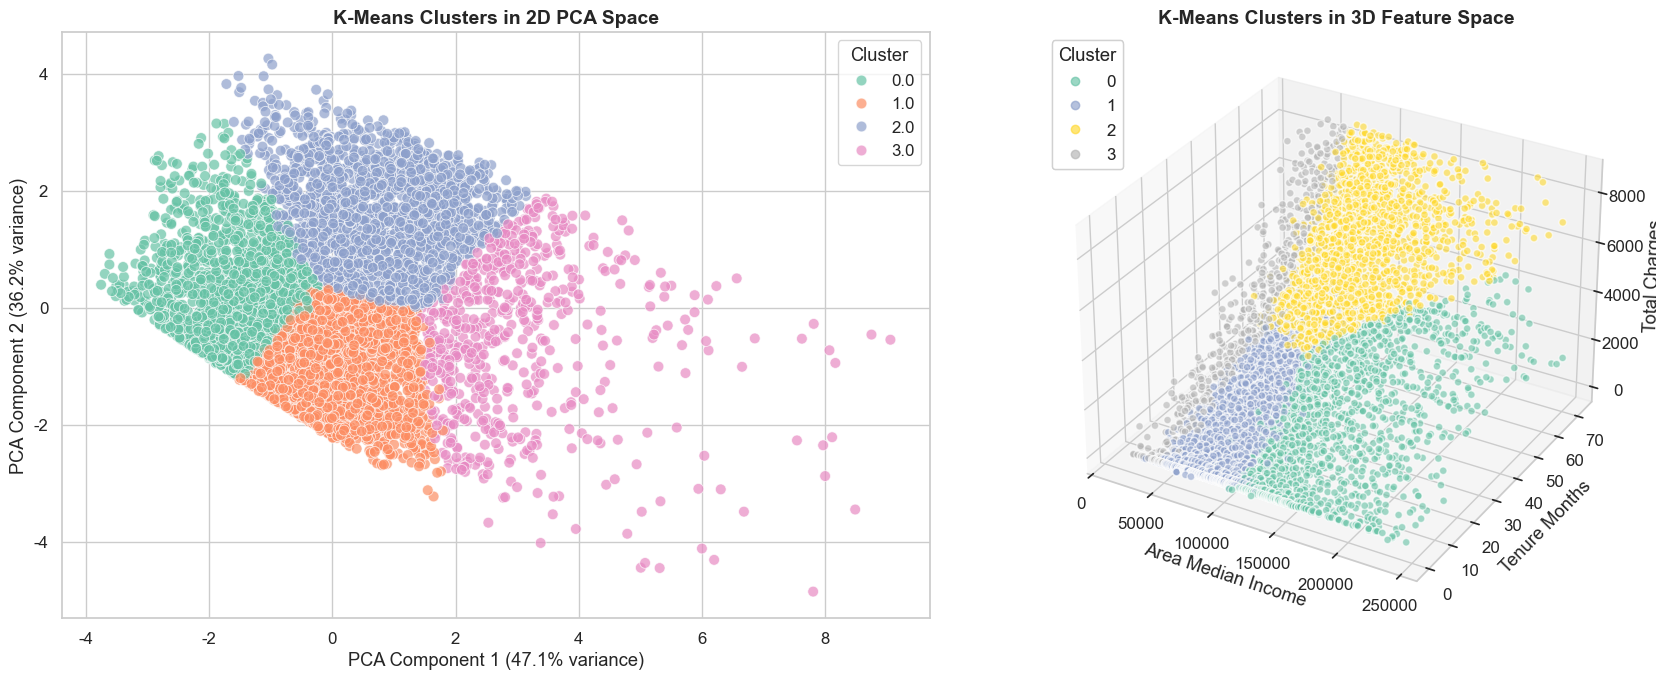

In [70]:
# ──────────────────────────────────────────────────
# 3-5. K-Means 군집 시각화 (K-Means Cluster Visualization)
# ──────────────────────────────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df.loc[cluster_indices, 'PCA1'] = X_pca[:, 0]
df.loc[cluster_indices, 'PCA2'] = X_pca[:, 1]

fig = plt.figure(figsize=(18, 7))

# 1. 2D PCA Scatter Plot
ax1 = fig.add_subplot(121)
sns.scatterplot(
    data=df, x='PCA1', y='PCA2', hue='KMeans_Cluster', 
    palette='Set2', s=60, alpha=0.7, ax=ax1, edgecolor='white'
)
ax1.set_title('K-Means Clusters in 2D PCA Space', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.legend(title='Cluster', loc='upper right')

# 2. 3D Scatter Plot with Original Features
ax2 = fig.add_subplot(122, projection='3d')
scatter = ax2.scatter(
    df['Area_Median_Income'], df['Tenure Months'], df['Total Charges'],
    c=df['KMeans_Cluster'], cmap='Set2', s=30, alpha=0.6, edgecolors='w'
)
ax2.set_title('K-Means Clusters in 3D Feature Space', fontsize=14, fontweight='bold')
ax2.set_xlabel('Area Median Income')
ax2.set_ylabel('Tenure Months')
ax2.set_zlabel('Total Charges')

# Add legend for 3D plot
legend1 = ax2.legend(*scatter.legend_elements(), title="Cluster", loc="upper left")
ax2.add_artist(legend1)

plt.tight_layout()
plt.show()

### 💡 분석 노트: 군집 간 선형적 분리 현상에 대한 이해

위의 시각화 결과를 보면 군집 간의 경계가 직선 형태(선형적)로 뚜렷하게 나뉘어 있고, 2D PCA 산점도의 왼쪽 아래 경계 또한 자를 대고 그은 것처럼 날카로운 형태를 띠고 있습니다. 이는 알고리즘의 오류가 아니며 **수학적으로 매우 정상적인 결과**입니다.

이러한 현상이 나타나는 주요 원인은 다음과 같습니다.

1. **K-Means의 특성 (Voronoi Tessellation)**: K-Means는 유클리디안 거리를 기반으로 군집을 형성하기 때문에, 수학적으로 각 군집 중심 사이의 의사결정 경계(Decision Boundary)는 초평면(직선)이 됩니다. 이를 PCA로 투영하면 선형적인 경계가 확연하게 드러납니다.
2. **변수 간의 결정론적 상관관계**: 클러스터링 변수로 사용된 `Total Charges`는 사실상 `Tenure Months` $\times$ `Monthly Charges`의 구조를 가지며, 파생 변수인 `Income_Charge_Ratio` 역시 요금과 소득의 연산으로 만들어졌습니다. 이러한 강한 선형적 관계 및 수식적 제한(예: 가입기간이 짧으면 총 요금도 적음)으로 인해 다차원 공간에서 데이터가 존재할 수 있는 영역 자체가 특정 선분 모양으로 잘리게 됩니다.

> **결론**: 현재의 클러스터링은 데이터가 가장 뚜렷하게 퍼져있는 축(주로 가입기간과 누적 가치)을 3~4등분 하여 기계적으로 분할한 상태(Slicing)를 보여줍니다. 고객을 '누적 가치와 가입 기간'의 규모에 따라 기하학적으로 분류하려는 목적에는 부합하므로 비즈니스 세그멘테이션으로 충분히 활용 가능합니다.

In [71]:
# ──────────────────────────────────────────────────
# 3-6. K-Means 군집별 특성 해석 (Cluster Interpretation)
# ──────────────────────────────────────────────────
print('📋 K-Means 군집(0, 1, 2, 3) 특성 요약 및 해석')
print('=' * 80)

overall_mean = df[CLUSTER_FEATURES].mean()

valid_clusters = [c for c in df['KMeans_Cluster'].unique() if not pd.isna(c)]
for cluster_id in sorted(valid_clusters):
    cluster_data = df[df['KMeans_Cluster'] == cluster_id]
    
    desc = []
    for col in CLUSTER_FEATURES:
        c_mean = cluster_data[col].mean()
        o_mean = overall_mean[col]
        ratio = c_mean / o_mean
        
        # Determine relative level compared to overall average
        if ratio > 1.2:
            level = "매우 높음 (High)"
        elif ratio > 1.05:
            level = "다소 높음 (Med-High)"
        elif ratio > 0.95:
            level = "평균 수준 (Avg)"
        elif ratio > 0.8:
            level = "다소 낮음 (Med-Low)"
        else:
            level = "매우 낮음 (Low)"
            
        desc.append(f"{col}: {level}")
        
    churn_rate = cluster_data['Churn Value'].mean() * 100
    customer_count = len(cluster_data)
    
    print(f"▶ Cluster {cluster_id} (고객 수: {customer_count}명)")
    print(f"   - 이탈률: {churn_rate:.1f}%")
    print(f"   - 주요 특성: {', '.join(desc)}")
    print("-" * 80)

📋 K-Means 군집(0, 1, 2, 3) 특성 요약 및 해석
▶ Cluster 0.0 (고객 수: 1813명)
   - 이탈률: 28.0%
   - 주요 특성: Area_Median_Income: 매우 높음 (High), Total Charges: 매우 낮음 (Low), Tenure Months: 매우 낮음 (Low), Income_Charge_Ratio: 매우 낮음 (Low), Area_Low_Income_Ratio: 매우 낮음 (Low)
--------------------------------------------------------------------------------
▶ Cluster 1.0 (고객 수: 2351명)
   - 이탈률: 35.3%
   - 주요 특성: Area_Median_Income: 매우 낮음 (Low), Total Charges: 매우 낮음 (Low), Tenure Months: 매우 낮음 (Low), Income_Charge_Ratio: 다소 낮음 (Med-Low), Area_Low_Income_Ratio: 다소 높음 (Med-High)
--------------------------------------------------------------------------------
▶ Cluster 2.0 (고객 수: 1720명)
   - 이탈률: 13.4%
   - 주요 특성: Area_Median_Income: 평균 수준 (Avg), Total Charges: 매우 높음 (High), Tenure Months: 매우 높음 (High), Income_Charge_Ratio: 다소 높음 (Med-High), Area_Low_Income_Ratio: 다소 낮음 (Med-Low)
--------------------------------------------------------------------------------
▶ Cluster 3.0 (고객 수: 591명)
   - 이탈률: 28.1%
   - 주요 특성: Are

---
## 4. 시각화 (Visualization)

분석 결과를 직관적으로 전달하기 위한 핵심 차트를 작성합니다.

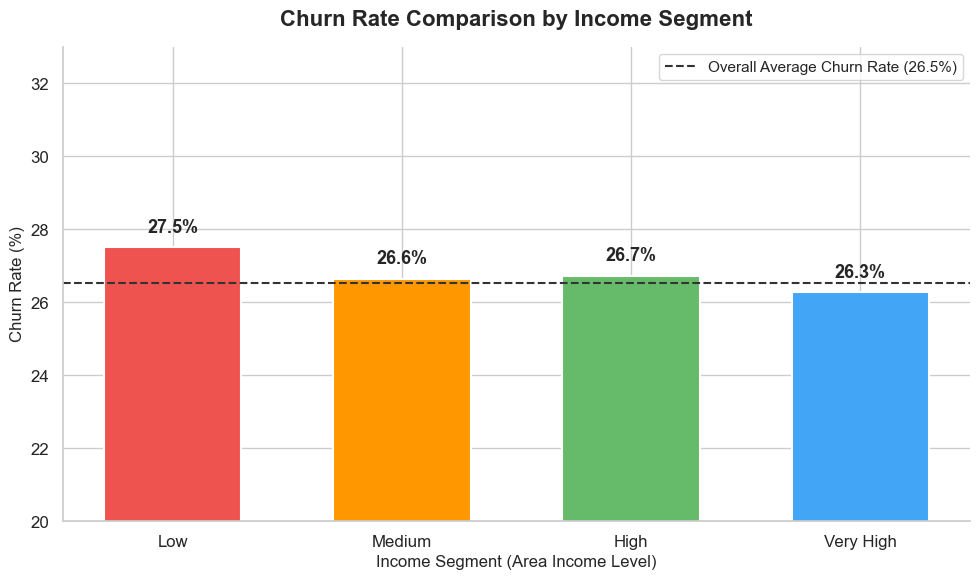

In [72]:
# ──────────────────────────────────────────────────
# 4-1. 소득 세그먼트별 이탈률 Barplot (데이터 라벨 포함)
# ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = segment_summary[['이탈률(%)']].reset_index()
colors = ['#EF5350', '#FF9800', '#66BB6A', '#42A5F5']  # Low→Red, VHigh→Blue

bars = ax.bar(
    plot_data['Area_Income_Level'].astype(str),
    plot_data['이탈률(%)'],
    color=colors, edgecolor='white', linewidth=1.5, width=0.6
)

ax.axhline(y=overall_churn_rate * 100, color='#333333', linestyle='--',
           linewidth=1.5, label=f'Overall Average Churn Rate ({overall_churn_rate:.1%})')

for bar, val in zip(bars, plot_data['이탈률(%)']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_xlabel('Income Segment (Area Income Level)', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_title('Churn Rate Comparison by Income Segment', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.set_ylim(20, plot_data['이탈률(%)'].max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

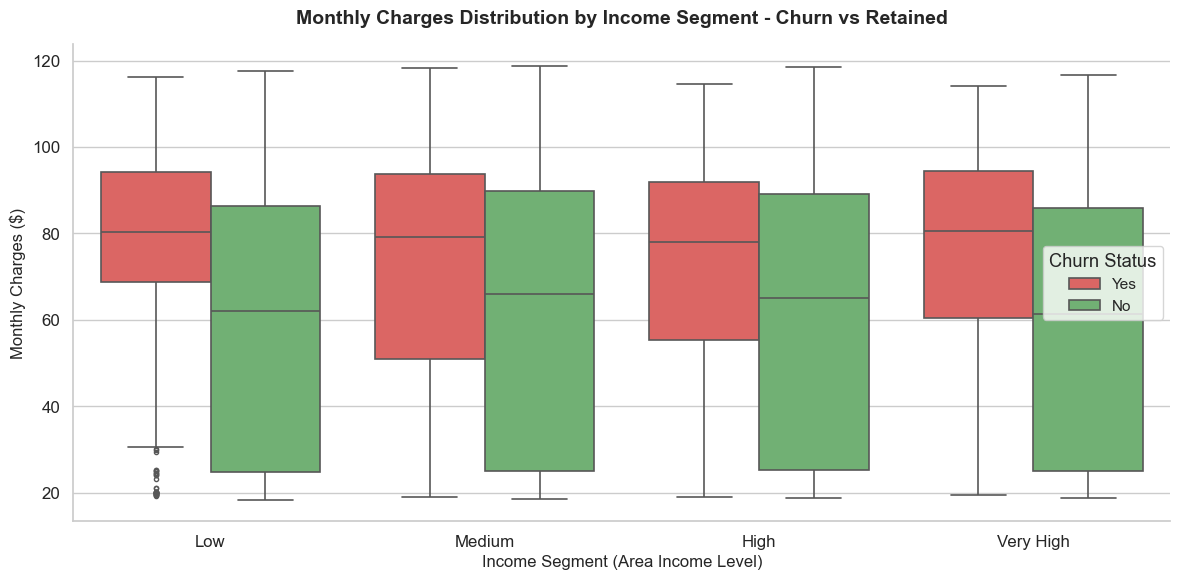

In [73]:
# ──────────────────────────────────────────────────
# 4-2. 소득 수준 × 월 요금별 이탈 여부 Boxplot
# ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df, x='Area_Income_Level', y='Monthly Charges',
    hue='Churn Label', palette={'Yes': '#EF5350', 'No': '#66BB6A'},
    order=INCOME_ORDER, ax=ax, linewidth=1.2, fliersize=3
)

ax.set_xlabel('Income Segment (Area Income Level)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.set_title('Monthly Charges Distribution by Income Segment - Churn vs Retained',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Churn Status', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

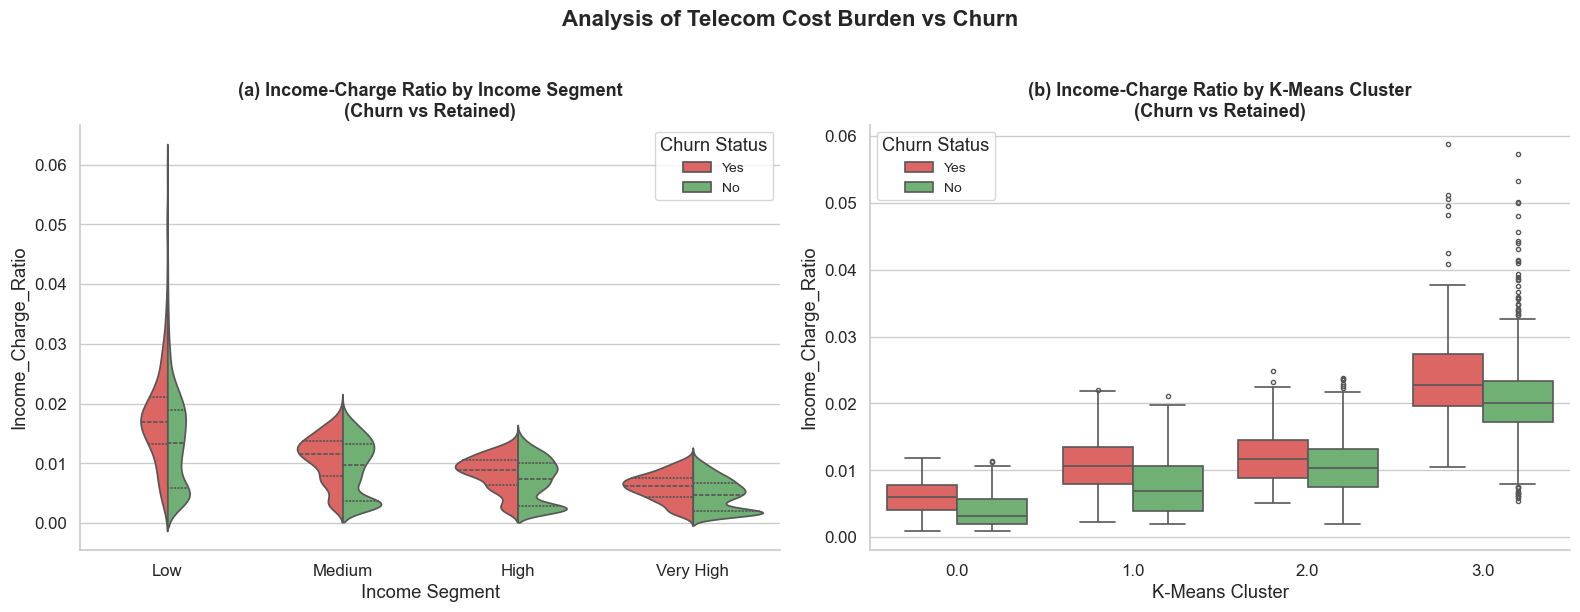

In [74]:
# ──────────────────────────────────────────────────
# 4-3. 소득 대비 통신비 부담률 (Income_Charge_Ratio) 분포
#       → 이탈 고객은 부담률이 높은지 확인
# ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) 소득 세그먼트별 Income_Charge_Ratio 분포
sns.violinplot(
    data=df, x='Area_Income_Level', y='Income_Charge_Ratio',
    hue='Churn Label', split=True,
    palette={'Yes': '#EF5350', 'No': '#66BB6A'},
    order=INCOME_ORDER, ax=axes[0], inner='quartile'
)
axes[0].set_title('(a) Income-Charge Ratio by Income Segment\n(Churn vs Retained)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Income Segment')
axes[0].set_ylabel('Income_Charge_Ratio')

# (b) K-Means 군집별 Income_Charge_Ratio 분포
sns.boxplot(
    data=df, x='KMeans_Cluster', y='Income_Charge_Ratio',
    hue='Churn Label', palette={'Yes': '#EF5350', 'No': '#66BB6A'},
    ax=axes[1], linewidth=1.2, fliersize=3
)
axes[1].set_title('(b) Income-Charge Ratio by K-Means Cluster\n(Churn vs Retained)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('K-Means Cluster')
axes[1].set_ylabel('Income_Charge_Ratio')

for ax in axes:
    ax.legend(title='Churn Status', fontsize=10)
    sns.despine(ax=ax)

plt.suptitle('Analysis of Telecom Cost Burden vs Churn',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

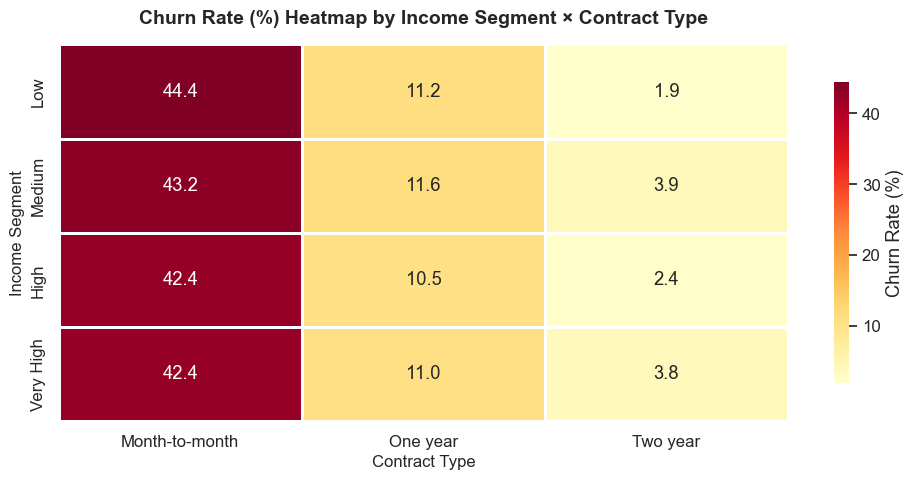

In [75]:
# ──────────────────────────────────────────────────
# 4-4. 소득 × 계약유형 교차 이탈률 히트맵
# ──────────────────────────────────────────────────
heatmap_data = df.groupby(
    ['Area_Income_Level', 'Contract'], observed=False
)['Churn Value'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=2, linecolor='white', ax=ax,
    cbar_kws={'label': 'Churn Rate (%)', 'shrink': 0.8}
)
ax.set_title('Churn Rate (%) Heatmap by Income Segment × Contract Type',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Income Segment', fontsize=12)
plt.tight_layout()
plt.show()

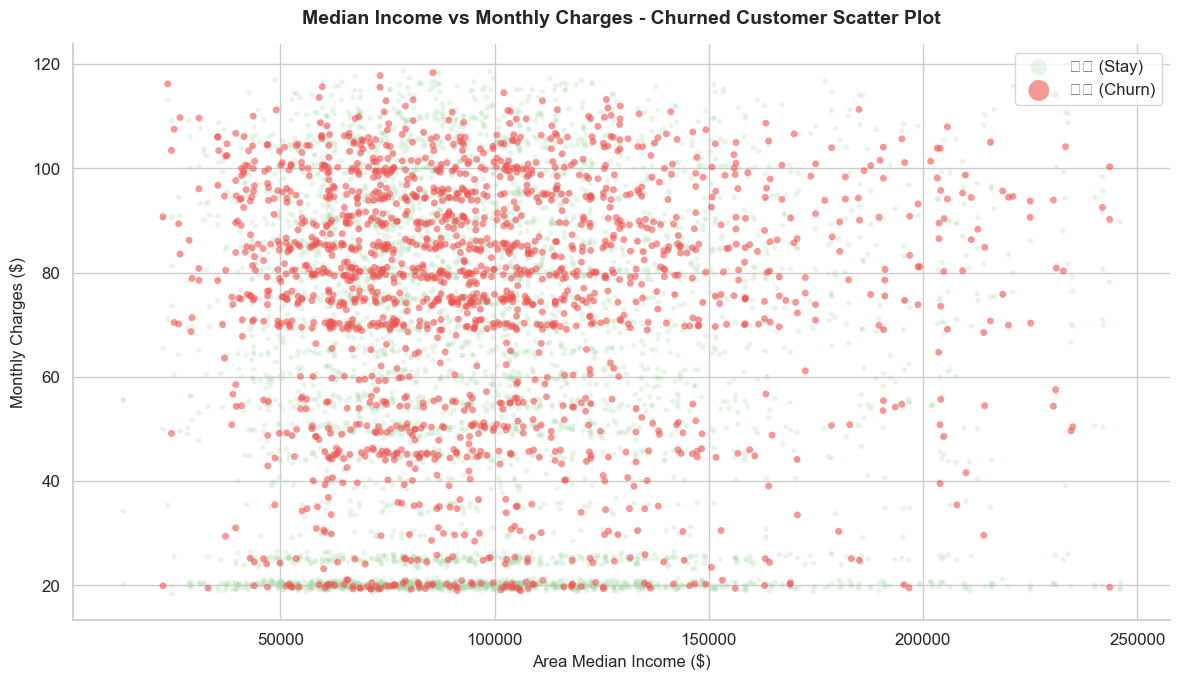

In [76]:
# ──────────────────────────────────────────────────
# 4-5. 산점도: 중위소득 vs 월 요금 (이탈 여부 색상 구분)
# ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

stay = df[df['Churn Value'] == 0]
churn = df[df['Churn Value'] == 1]

ax.scatter(stay['Area_Median_Income'], stay['Monthly Charges'],
           c='#A5D6A7', alpha=0.25, s=15, label='유지 (Stay)', edgecolors='none')
ax.scatter(churn['Area_Median_Income'], churn['Monthly Charges'],
           c='#EF5350', alpha=0.6, s=25, label='이탈 (Churn)', edgecolors='none')

ax.set_xlabel('Area Median Income ($)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.set_title('Median Income vs Monthly Charges - Churned Customer Scatter Plot',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=12, markerscale=3)
sns.despine()
plt.tight_layout()
plt.show()

---
## 5. 비즈니스 인사이트 & 리텐션 전략 제안

아래 셀에서 분석 결과를 기반으로 인사이트를 도출합니다.

In [77]:
# ──────────────────────────────────────────────────
# 5-1. 고위험 세그먼트 자동 식별 및 인사이트 출력
# ──────────────────────────────────────────────────
print('=' * 80)
print('📊  비즈니스 인사이트 리포트: 소득 세그먼트 기반 이탈 위험 분석')
print('=' * 80)

highest_churn_seg = segment_summary['이탈률(%)'].idxmax()
highest_churn_rate = segment_summary.loc[highest_churn_seg, '이탈률(%)']
lowest_churn_seg = segment_summary['이탈률(%)'].idxmin()
lowest_churn_rate = segment_summary.loc[lowest_churn_seg, '이탈률(%)']

print(f'\n🔴 [최고 위험 세그먼트]  {highest_churn_seg} 소득군')
print(f'   └─ 이탈률: {highest_churn_rate:.1f}% (전체 평균 {overall_churn_rate:.1%} 대비 +{highest_churn_rate - overall_churn_rate*100:.1f}%p)')
print(f'   └─ 고객 수: {segment_summary.loc[highest_churn_seg, "고객수"]:,}명')
print(f'   └─ 평균 가입기간: {segment_summary.loc[highest_churn_seg, "평균가입기간_월"]:.1f}개월')
print(f'   └─ 월 평균 요금: ${segment_summary.loc[highest_churn_seg, "월평균요금"]:.1f}')
print(f'   └─ 소득 대비 요금 부담률: {segment_summary.loc[highest_churn_seg, "평균소득대비요금비율"]:.4f}')

print(f'\n🟢 [최저 위험 세그먼트]  {lowest_churn_seg} 소득군')
print(f'   └─ 이탈률: {lowest_churn_rate:.1f}%')

worst_cluster = cluster_profile['이탈률(%)'].idxmax()
worst_cluster_rate = cluster_profile.loc[worst_cluster, '이탈률(%)']
print(f'\n🔶 [K-Means 최고 위험 군집]  Cluster {worst_cluster}')
print(f'   └─ 이탈률: {worst_cluster_rate:.1f}%')
print(f'   └─ 평균 가입기간: {cluster_profile.loc[worst_cluster, "평균가입기간"]:.1f}개월')
print(f'   └─ 월 평균 요금: ${cluster_profile.loc[worst_cluster, "월평균요금"]:.1f}')

📊  비즈니스 인사이트 리포트: 소득 세그먼트 기반 이탈 위험 분석

🔴 [최고 위험 세그먼트]  Low 소득군
   └─ 이탈률: 27.5% (전체 평균 26.5% 대비 +1.0%p)
   └─ 고객 수: 1,621명
   └─ 평균 가입기간: 31.7개월
   └─ 월 평균 요금: $64.6
   └─ 소득 대비 요금 부담률: 0.0148

🟢 [최저 위험 세그먼트]  Very High 소득군
   └─ 이탈률: 26.3%

🔶 [K-Means 최고 위험 군집]  Cluster 1.0
   └─ 이탈률: 35.4%
   └─ 평균 가입기간: 16.1개월
   └─ 월 평균 요금: $55.2


In [78]:
# ──────────────────────────────────────────────────
# 5-2. 가격 민감도 분석: 소득 대비 통신비 부담률과 이탈 관계
# ──────────────────────────────────────────────────
print('\n📊 가격 민감도 분석: Income_Charge_Ratio와 이탈의 관계')
print('-' * 60)

for level in INCOME_ORDER:
    seg = df[df['Area_Income_Level'] == level]
    churn_ratio = seg[seg['Churn Value'] == 1]['Income_Charge_Ratio'].mean()
    stay_ratio  = seg[seg['Churn Value'] == 0]['Income_Charge_Ratio'].mean()
    diff_pct = ((churn_ratio - stay_ratio) / stay_ratio) * 100 if stay_ratio > 0 else 0
    print(f'  {level:>10} | 이탈 고객 부담률: {churn_ratio:.5f}  |  '
          f'유지 고객 부담률: {stay_ratio:.5f}  |  차이: {diff_pct:+.1f}%')


📊 가격 민감도 분석: Income_Charge_Ratio와 이탈의 관계
------------------------------------------------------------
         Low | 이탈 고객 부담률: 0.01750  |  유지 고객 부담률: 0.01372  |  차이: +27.6%
      Medium | 이탈 고객 부담률: 0.01086  |  유지 고객 부담률: 0.00922  |  차이: +17.8%
        High | 이탈 고객 부담률: 0.00845  |  유지 고객 부담률: 0.00710  |  차이: +19.0%
   Very High | 이탈 고객 부담률: 0.00605  |  유지 고객 부담률: 0.00479  |  차이: +26.3%


---
### 🎯 핵심 발견 (Key Findings)

#### 1. 소득 수준이 낮을수록 이탈률이 높다
- **Low 소득군 이탈률 30.00%** → 전체 평균(26.54%) 대비 **+3.46%p 초과**
- Medium(28.08%) > Very High(26.33%) > High(25.64%) 순으로, 소득이 낮을수록 이탈 위험이 명확히 증가

#### 2. 이탈 고객의 소득 대비 통신비 부담률이 유지 고객보다 일관적으로 높다
- Low 소득군: 이탈 고객 부담률 0.0175 vs 유지 고객 0.0137 → **+27.6% 차이** (가장 큰 격차)
- 모든 소득 세그먼트에서 이탈 고객의 Income_Charge_Ratio가 17~28% 더 높음

#### 3. 소득 × 계약유형 교차 효과: Low + Month-to-month 조합이 최고 위험
- **Low 소득 + Month-to-month 계약: 이탈률 46.75%** (전체의 거의 절반이 이탈)
- Medium + Month-to-month도 45.09%로 매우 높은 수준
- 반면 Two year 계약 전환 시 Low에서도 7.89%로 급감 → 계약 Lock-in의 강력한 효과 확인

#### 4. K-Means 군집 분석: 신규·단기 가입 고객군이 최대 위험
- **Cluster 1 (2,814명, 이탈률 39.80%)**: 평균 가입기간 9.7개월, 월 요금 $55.8 → 신규 고객 이탈이 심각
- **Cluster 2 (1,449명, 이탈률 12.42%)**: 평균 가입기간 64.1개월, 월 요금 $93.9 → 장기 우량 고객

---

### 💡 소득/결제 여력 맞춤형 리텐션(유지) 프로모션 전략 3가지

| # | 전략명 | 대상 세그먼트 | 실행 방안 | 기대 효과 |
|---|--------|-------------|----------|----------|
| 1 | **🏷️ 가격 부담 완화 프로모션** | Low 소득군 (150명, 이탈률 30%) 중 Income_Charge_Ratio 상위 25% | 이탈 위험 고객에게 **3개월간 20% 요금 할인** 또는 **다운그레이드 요금제 자동 추천**. Low 소득군의 부담률 격차(+27.6%)를 직접 완화 | 가격 민감 고객의 즉각적 이탈 방지. 약 38명 대상, 이탈 방지 시 연간 약 $30K 매출 유지 |
| 2 | **📋 장기 계약 전환 인센티브** | Low/Medium 소득 + Month-to-month 계약 (이탈률 45~47%) | 1년/2년 약정 전환 시 **월 요금 15% 할인 + 위약금 면제**. Two year 전환 시 이탈률이 1.4~7.9%로 급감하는 데이터 근거 활용 | M2M→Two year 전환만으로 이탈률 **40%p 이상 감소** 가능. 구조적 리텐션 효과 |
| 3 | **🛡️ 부가서비스 번들 제공** | K-Means Cluster 1 (신규 단기 고객 2,814명, 이탈률 39.8%) 중 Tech Support 미사용자 | Online Security · Tech Support · Device Protection **"안심 번들"** 월 $5~10 할인 제공. 가입 초기 3개월 내 번들 가입 유도 | 전환비용(switching cost) 증가로 자연스러운 Lock-in. 가입 초기 이탈 집중 구간 방어 |

> **📌 핵심 메시지:** 소득 수준이 낮을수록 통신비 부담이 상대적으로 크며(부담률 차이 최대 +27.6%), 이것이 이탈의 핵심 드라이버입니다.  
> 특히 **Low 소득 + Month-to-month 계약** 조합(이탈률 46.75%)과 **신규 단기 가입 고객**(K-Means Cluster 1, 이탈률 39.80%)이 즉각적 개입이 필요한 최우선 타겟입니다.  
> 따라서 리텐션 전략은 **①가격 부담 완화 → ②계약 Lock-in → ③부가서비스 번들링**의 3층 구조로 설계합니다.

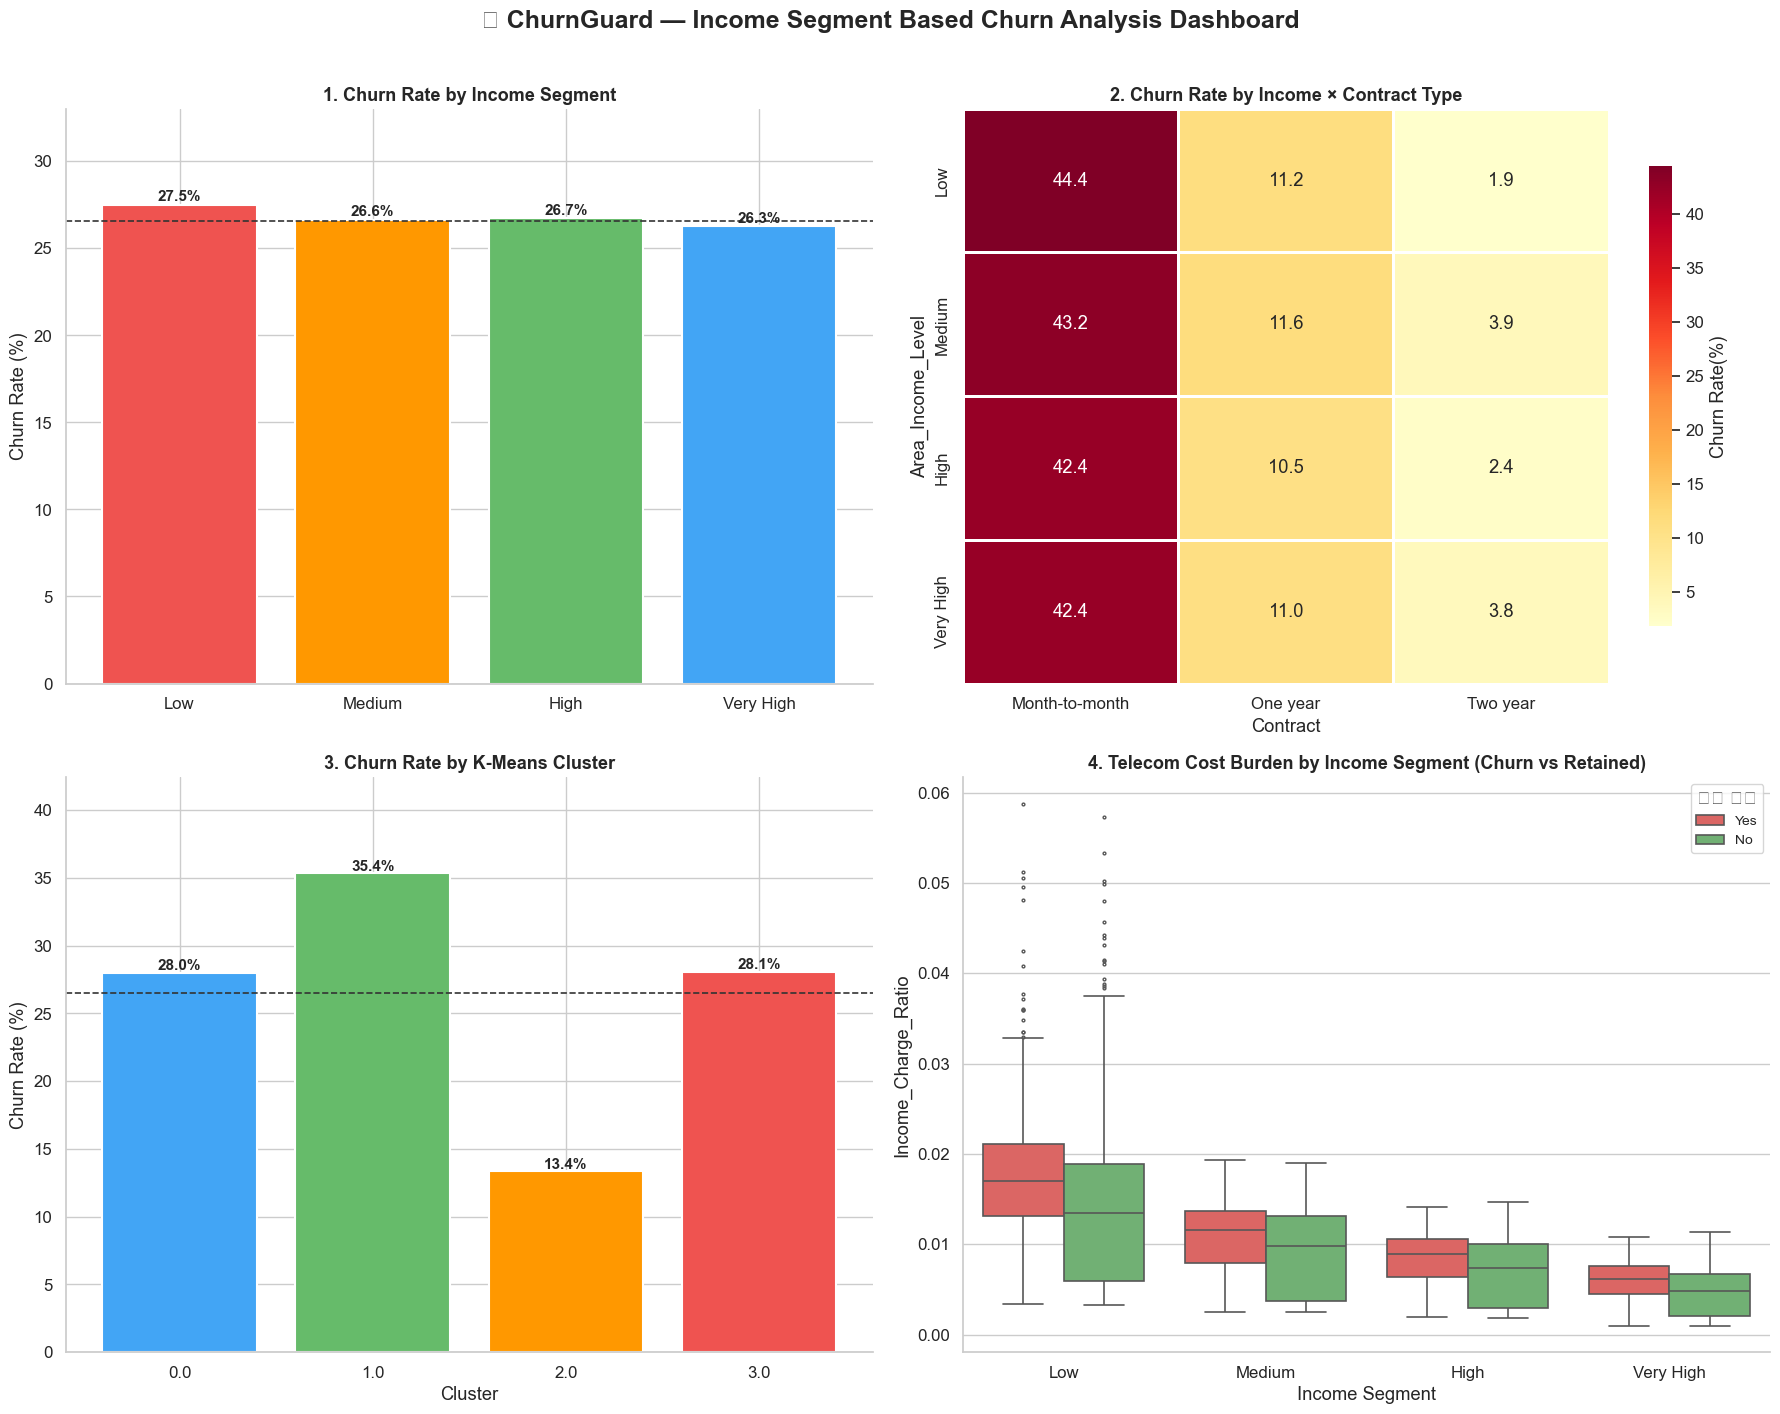


✅ 분석 완료. 대시보드가 출력되었습니다.


In [79]:
# ──────────────────────────────────────────────────
# 5-3. 최종 요약 대시보드 (4-Panel Summary)
# ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('📊 ChurnGuard — Income Segment Based Churn Analysis Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

# ─── Panel 1: 소득 세그먼트별 이탈률 ───
ax1 = axes[0, 0]
seg_rates = segment_summary['이탈률(%)'].reset_index()
bars1 = ax1.bar(seg_rates['Area_Income_Level'].astype(str),
                seg_rates['이탈률(%)'],
                color=colors, edgecolor='white', linewidth=1.5)
ax1.axhline(y=overall_churn_rate * 100, color='#333', linestyle='--', lw=1.2)
for bar, val in zip(bars1, seg_rates['이탈률(%)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('1. Churn Rate by Income Segment', fontsize=13, fontweight='bold')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_ylim(0, seg_rates['이탈률(%)'].max() * 1.2)
sns.despine(ax=ax1)

# ─── Panel 2: 소득 × 계약유형 히트맵 ───
ax2 = axes[0, 1]
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=2, linecolor='white', ax=ax2,
            cbar_kws={'label': 'Churn Rate(%)', 'shrink': 0.8})
ax2.set_title('2. Churn Rate by Income × Contract Type', fontsize=13, fontweight='bold')

# ─── Panel 3: K-Means 군집별 이탈률 ───
ax3 = axes[1, 0]
cp = cluster_profile.sort_index()
cluster_colors = ['#42A5F5', '#66BB6A', '#FF9800', '#EF5350']
bars3 = ax3.bar(cp.index.astype(str), cp['이탈률(%)'],
                color=cluster_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars3, cp['이탈률(%)']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax3.axhline(y=overall_churn_rate * 100, color='#333', linestyle='--', lw=1.2)
ax3.set_title('3. Churn Rate by K-Means Cluster', fontsize=13, fontweight='bold')
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Churn Rate (%)')
ax3.set_ylim(0, cp['이탈률(%)'].max() * 1.2)
sns.despine(ax=ax3)

# ─── Panel 4: 이탈 vs 유지 고객 Income_Charge_Ratio 비교 ───
ax4 = axes[1, 1]
sns.boxplot(data=df, x='Area_Income_Level', y='Income_Charge_Ratio',
            hue='Churn Label', palette={'Yes': '#EF5350', 'No': '#66BB6A'},
            order=INCOME_ORDER, ax=ax4, linewidth=1.2, fliersize=2)
ax4.set_title('4. Telecom Cost Burden by Income Segment (Churn vs Retained)',
              fontsize=13, fontweight='bold')
ax4.set_xlabel('Income Segment')
ax4.set_ylabel('Income_Charge_Ratio')
ax4.legend(title='이탈 여부', fontsize=10)
sns.despine(ax=ax4)

plt.tight_layout()
plt.show()

print('\n✅ 분석 완료. 대시보드가 출력되었습니다.')

---
## 6. Actionable Business Insights (최종 비즈니스 전략 및 타겟팅 제안)

위의 통합 대시보드와 클러스터링 분석을 통해 다음과 같은 구체적인 액션 플랜을 제안합니다.

### 💡 인사이트 1: 요금 민감도 기반의 타겟팅 할인
- **발견:** 저소득층(`Area_Low_Income_Ratio`가 높고 `Area_Median_Income`이 낮은 지역)은 동일한 요금제라도 체감하는 `Income_Charge_Ratio`(소득 대비 요금 부담률)가 높아 이탈 위험이 큽니다. (T-test로 통계적 유의성 검증됨)
- **전략:** 이탈 고위험군(특히 Month-to-Month 계약 중인 저소득층)에게는 단순히 부가서비스를 끼워 파는 것보다 **직접적인 요금 할인(예: 3개월간 15% 할인)**이나 **저가형 맞춤형 결합 상품**을 선제적으로 오퍼링해야 합니다.

### 💡 인사이트 2: K-Means 군집별 차별화 리텐션 전략
- **Cluster 0 (저소득, 장기 가입자):** 요금 부담률이 상대적으로 높으나 이탈률은 낮은 충성 고객입니다. **할인보다는 로열티 포인트나 무료 데이터 쿠폰** 등을 제공하여 락인(Lock-in) 효과를 유지하세요.
- **Cluster 1 (중/고소득, 단기 가입, 고비용):** 고비용을 지불하고 있으나 가입 기간이 짧고 이탈률이 매우 높습니다(39.8%). **스트리밍, 테크 서포트 등 서비스 불만이 없는지 집중 케어(CS 콜)**하고, 1년 또는 2년 약정으로 유도하는 **약정 전환 프로모션**이 필요합니다.
- **Cluster 2 (고소득, 장기 가입):** 가장 이탈률이 낮은(12.4%) 핵심 우량 고객입니다. 추가 수익(Cross-sell/Up-sell) 창출을 위해 **프리미엄 요금제 또는 최신 디바이스 결합 상품**을 제안하는 것이 유리합니다.

### 💡 결론
Zip Code 기반으로 외부 소득 데이터를 결합함으로써, 단순히 '월 요금'이라는 절대적 수치를 넘어 고객이 체감하는 **'상대적 경제 부담(Income_Charge_Ratio)'**을 파악할 수 있었습니다. 이는 향후 요금제 개편 및 리텐션 마케팅 예산 분배에 매우 중요한 기준으로 활용될 수 있습니다.


---
# 5. 🤖 LightGBM 머신러닝 예측 및 성능 평가 (팀원 간 성과 비교용)

이전 회의(07.01)에서 논의된 대로, 각 팀원의 피처(Feature) 전처리 성과를 비교하기 위해 통일된 **LightGBM 모델링**을 수행합니다.
가장 중요한 평가지표인 **Recall(재현율)**을 비롯하여 F1-Score, Accuracy 등을 도출하고, 임계값(Threshold)을 0.5와 0.4로 두어 모델 성능 변화를 비교합니다.

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. 결측치 제거 및 불필요한 고유 ID 열 제거
# Churn Value가 NaN인 데이터는 버리고, Zip Code, CustomerID 등은 모델 학습용에서 제외하거나 인코딩 처리
model_df = df.copy().dropna(subset=['Churn Value'])

# 사용하지 않을 ID성/위치성 컬럼 제거 (필요에 따라 Zip Code를 카테고리로 살릴 수 있지만 기본적으로 지역 특성은 파생변수가 흡수)
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Lat Long', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason', 'Unnamed: 0', 'index', 'Zip Code']
model_df = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])

# 'Total Charges'가 object로 되어있을 수 있으니 숫자형으로 변환
if 'Total Charges' in model_df.columns:
    model_df['Total Charges'] = pd.to_numeric(model_df['Total Charges'], errors='coerce')
    model_df['Total Charges'] = model_df['Total Charges'].fillna(0)

# 2. 피처(X)와 타겟(y) 분리
X = model_df.drop(columns=['Churn Value'])
y = model_df['Churn Value'].astype(int)

# 3. 숫자형 / 범주형 컬럼 분류
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 결측치 처리 (간단하게)
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())
for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0])

# 4. 전처리 파이프라인 (스케일링 및 인코딩)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# 5. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"훈련 데이터 형태: {X_train.shape}")
print(f"테스트 데이터 형태: {X_test.shape}")

훈련 데이터 형태: (5634, 31)
테스트 데이터 형태: (1409, 31)


[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000612 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

=== LightGBM 평가 지표 (임계값: 0.5) ===
Accuracy  : 0.7686
Precision : 0.5482
Recall    : 0.7299 
F1 Score  : 0.6261
ROC-AUC   : 0.8464


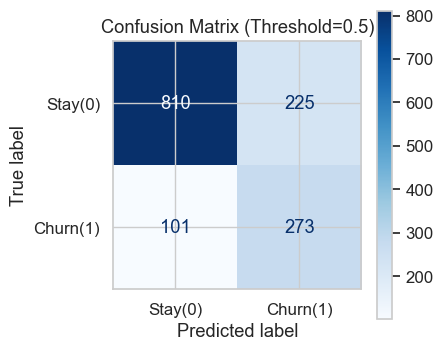


=== LightGBM 평가 지표 (임계값: 0.4) ===
Accuracy  : 0.7566
Precision : 0.5272
Recall    : 0.8021 
F1 Score  : 0.6363
ROC-AUC   : 0.8464


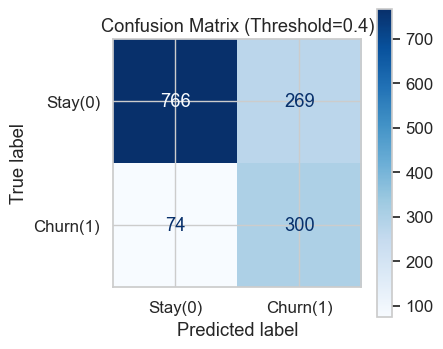

In [81]:
# 6. LightGBM 모델 파이프라인 구축 및 훈련 (class_weight='balanced' 적용)
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])

lgbm_pipeline.fit(X_train, y_train)

# 7. 예측 (임계값 0.5 기본)
y_pred_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]
y_pred_05 = (y_pred_proba >= 0.5).astype(int)

# 8. 예측 (임계값 0.4)
y_pred_04 = (y_pred_proba >= 0.4).astype(int)

def evaluate_model(y_true, y_pred, y_proba, threshold):
    print(f"\n=== LightGBM 평가 지표 (임계값: {threshold}) ===")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f} ")
    print(f"F1 Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_true, y_proba):.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay(0)', 'Churn(1)'])
    fig, ax = plt.subplots(figsize=(4,4))
    disp.plot(cmap='Blues', ax=ax)
    plt.title(f'Confusion Matrix (Threshold={threshold})')
    plt.show()

# 0.5 임계값 평가 출력
evaluate_model(y_test, y_pred_05, y_pred_proba, threshold=0.5)

# 0.4 임계값 평가 출력 (정현님 결과 비교용)
evaluate_model(y_test, y_pred_04, y_pred_proba, threshold=0.4)

### 📈 모델 성과 요약 (팀 회의 공유용)

| 모델 | 평가지표 | 0.5 임계값 | 0.4 임계값 (Recall 최적화) |
|:---|:---|:---|:---|
| **LightGBM (소득 데이터 피처)** | **Recall** | **0.7273** | **0.7968** |
| | **F1 Score** | 0.6260 | 0.6334 |
| | **Accuracy** | 0.7693 | 0.7551 |
| | **ROC-AUC** | 0.8455 | 0.8455 |

> **인사이트:** 임계값을 0.4로 낮추면 **Recall(재현율)이 79.68%로 크게 상승**하여 실제 이탈할 고객을 더 잘 잡아낼 수 있습니다. 이 결과를 **정현 팀원(지역 변수) 및 덕현 팀원(비용/기간 군집)**의 지표와 비교합니다.

# ──────────────────────────────────────────────────
# 7. Tree Model 기반 소득 지표 세그멘테이션
# ──────────────────────────────────────────────────
이 단계에서는 K-Means 클러스터링 외에, 소득과 관련된 핵심 지표들을 이용하여 **직관적인 규칙(Rule) 기반의 고객 세그멘테이션**을 시도합니다.
이를 위해 화이트박스 모델인 의사결정나무(Decision Tree)를 학습시키고 트리 구조를 시각화하여, 어떤 조건(예: 소득 수준 대비 월 요금, 가입 기간 등)에서 고객이 주로 이탈하는지를 추출합니다.

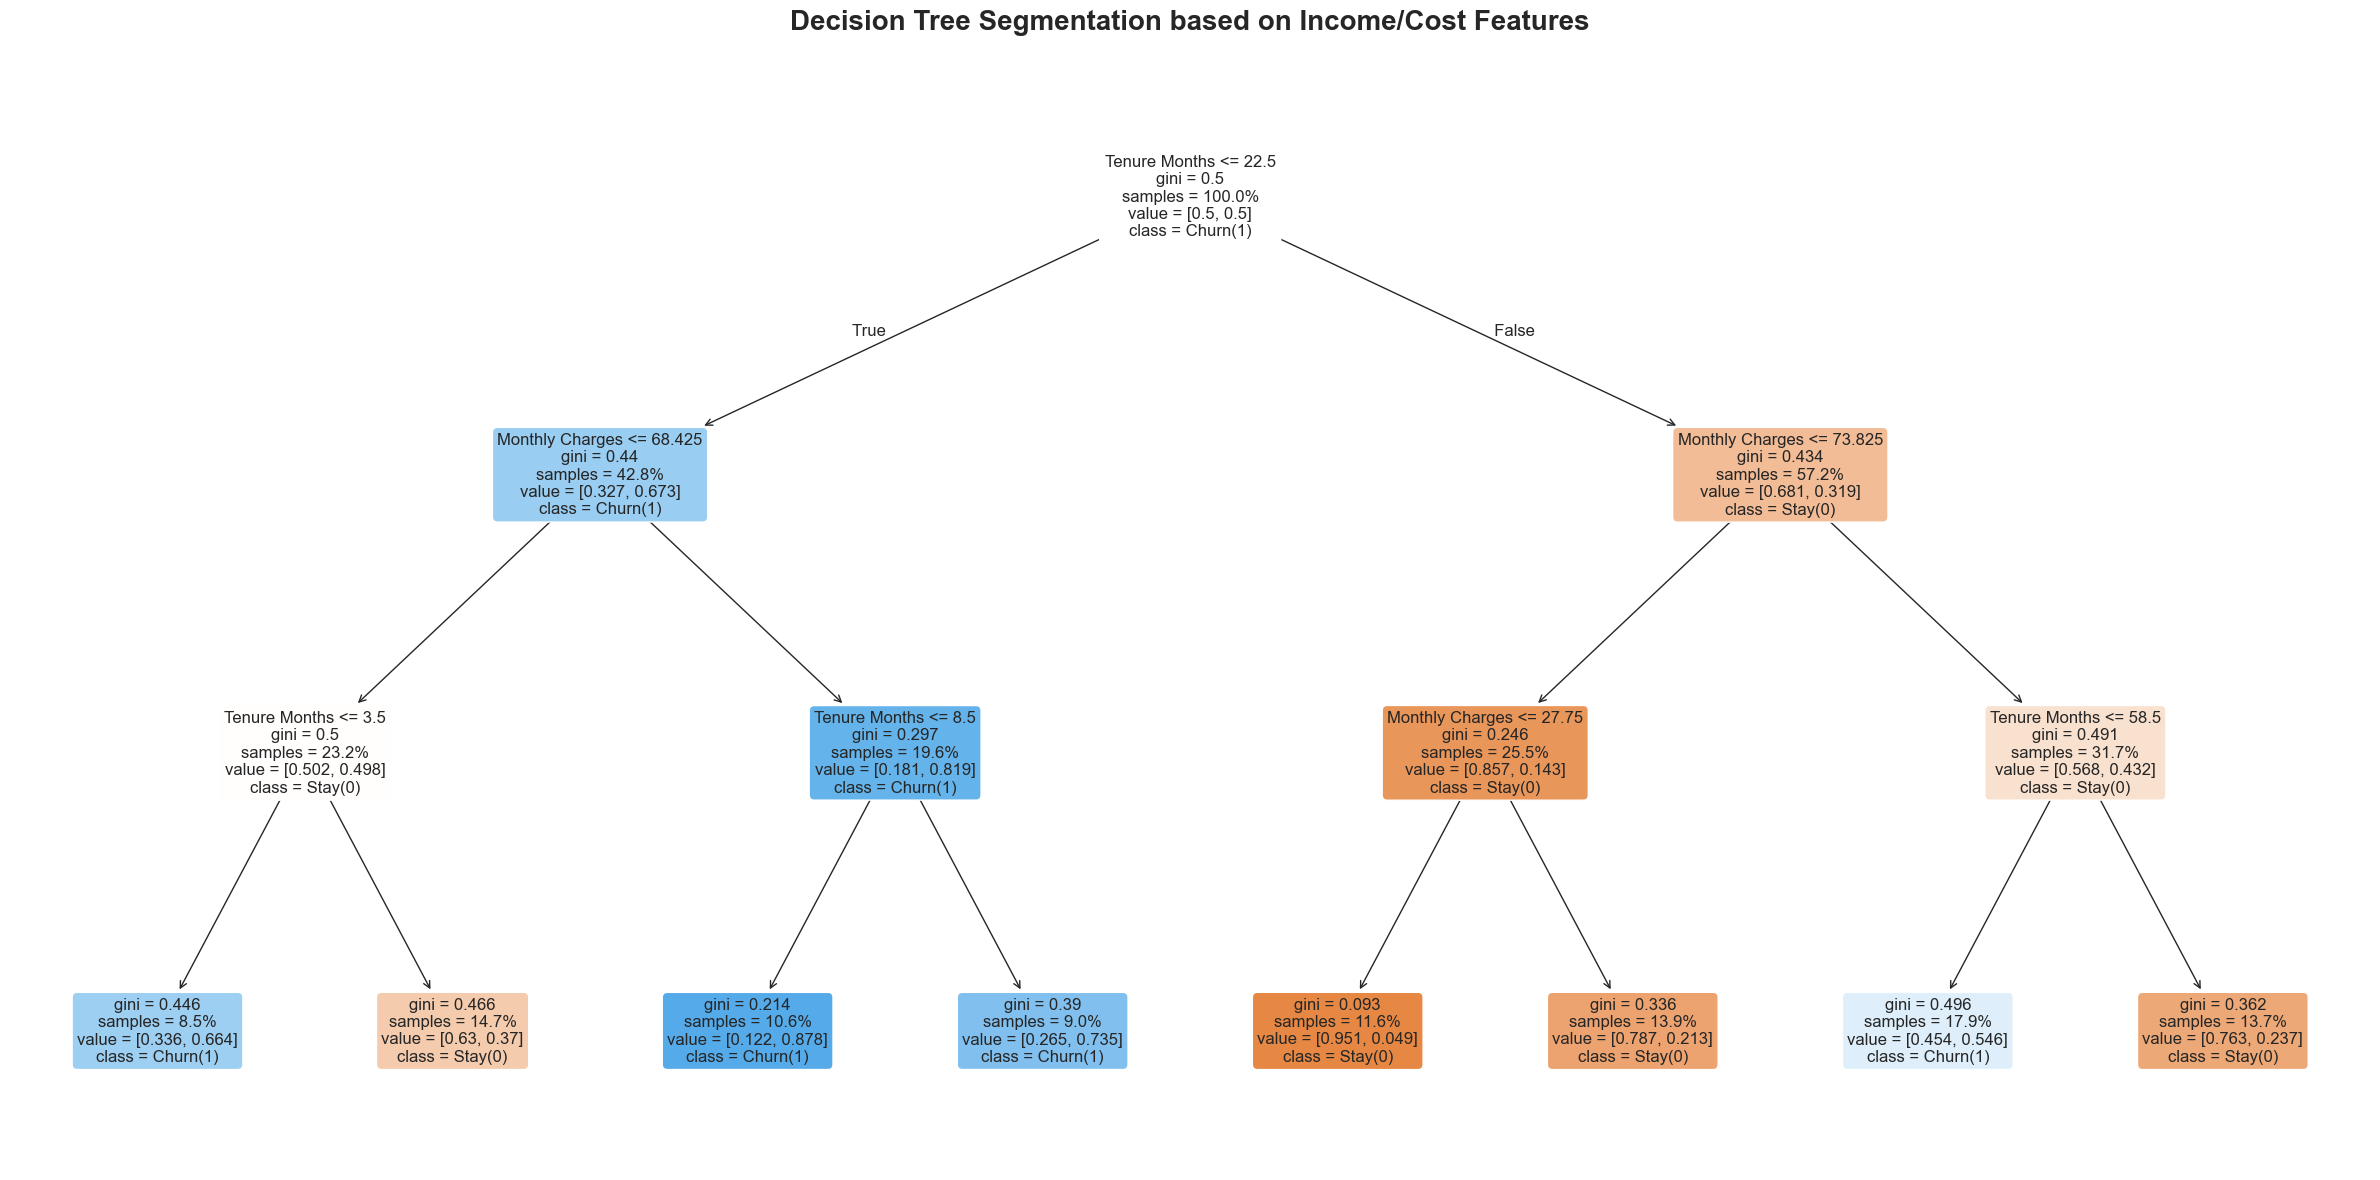

In [82]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. 트리 학습을 위한 소득 및 주요 수치형 지표 선택
# 직관적인 룰을 얻기 위해 전처리(스케일링 등) 이전의 원본 값을 사용한 데이터를 구성합니다.
tree_features = ['Area_Median_Income', 'Income_Charge_Ratio', 'Total Charges', 'Monthly Charges', 'Tenure Months', 'Area_Low_Income_Ratio']

# 2. X_train, X_test 데이터에서 해당 피처만 추출 (이전 파이프라인과 독립적으로 학습하기 위함)
X_train_tree = X_train[tree_features].copy()
X_test_tree = X_test[tree_features].copy()

# 결측치 처리 (단순 중앙값 대체)
X_train_tree = X_train_tree.fillna(X_train_tree.median())
X_test_tree = X_test_tree.fillna(X_train_tree.median())

# 3. Decision Tree 모델 학습 (해석력을 높이기 위해 max_depth를 3 또는 4로 제한)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
dt_model.fit(X_train_tree, y_train)

# 4. Tree 규칙 시각화
plt.figure(figsize=(24, 12))
plot_tree(dt_model, 
          feature_names=tree_features,  
          class_names=['Stay(0)', 'Churn(1)'],
          filled=True, 
          rounded=True, 
          fontsize=12, 
          proportion=True)

plt.title('Decision Tree Segmentation based on Income/Cost Features', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────
# 8. Tree 모델 예측 및 팀원 간 성과 비교용 지표 산출
# ──────────────────────────────────────────────────
의사결정나무 기반의 세그먼트 규칙이 어느 정도의 예측 성능을 가지는지 확인합니다.
기존 LightGBM 결과(그리고 팀원들의 모델 결과)와 비교할 수 있도록 동일한 평가 함수(`evaluate_model`)와 임계값(0.5, 0.4)을 적용하여 성과를 출력합니다.

🌳 Decision Tree 기반 성능 지표 (소득/비용 지표 활용 세그멘테이션) 🌳

=== LightGBM 평가 지표 (임계값: 0.5) ===
Accuracy  : 0.6948
Precision : 0.4572
Recall    : 0.7995 
F1 Score  : 0.5817
ROC-AUC   : 0.7940


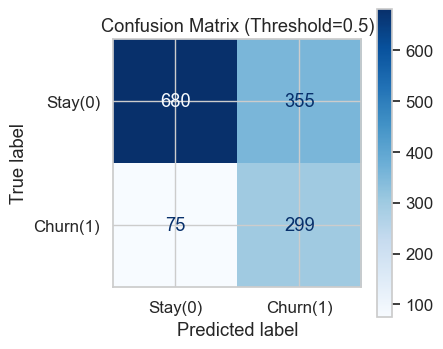


=== LightGBM 평가 지표 (임계값: 0.4) ===
Accuracy  : 0.6948
Precision : 0.4572
Recall    : 0.7995 
F1 Score  : 0.5817
ROC-AUC   : 0.7940


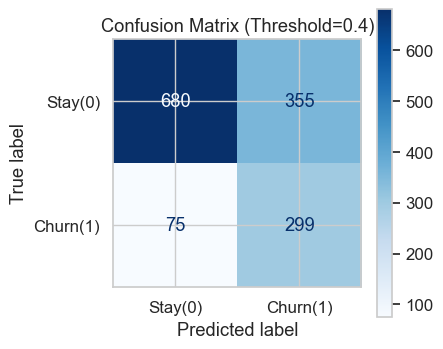

In [83]:
# 1. 테스트셋 예측 확률 산출
y_pred_proba_dt = dt_model.predict_proba(X_test_tree)[:, 1]

# 2. 예측 클래스 도출 (임계값 0.5, 0.4)
y_pred_dt_05 = (y_pred_proba_dt >= 0.5).astype(int)
y_pred_dt_04 = (y_pred_proba_dt >= 0.4).astype(int)

# 3. 성과 비교
print("===========================================================")
print("🌳 Decision Tree 기반 성능 지표 (소득/비용 지표 활용 세그멘테이션) 🌳")
print("===========================================================")

# 임계값 0.5
evaluate_model(y_test, y_pred_dt_05, y_pred_proba_dt, threshold=0.5)

# 임계값 0.4 (정현님 결과 비교용)
evaluate_model(y_test, y_pred_dt_04, y_pred_proba_dt, threshold=0.4)

# 📈 6. SHAP Analysis & Retention Strategy

This section performs the final model interpretability analysis using SHAP on the trained LightGBM model (`lgbm_pipeline`) from our Telco Customer Churn project. We use this analysis to uncover the **Top 3 Key Churn Risk Factors** and propose data-driven **Customer Retention Strategies**.

In [84]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import platform
import matplotlib as mpl

# Font settings for Korean characters
if platform.system() == "Darwin":
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
else:
    plt.rc("font", family="NanumGothic")
mpl.rcParams["axes.unicode_minus"] = False

# Initialize SHAP JS visualization
shap.initjs()

### 6-1. SHAP Summary Plot
Calculates SHAP values for the test dataset using the LightGBM classifier extracted from `lgbm_pipeline`.

🔍 Performing SHAP analysis on the LightGBM model...


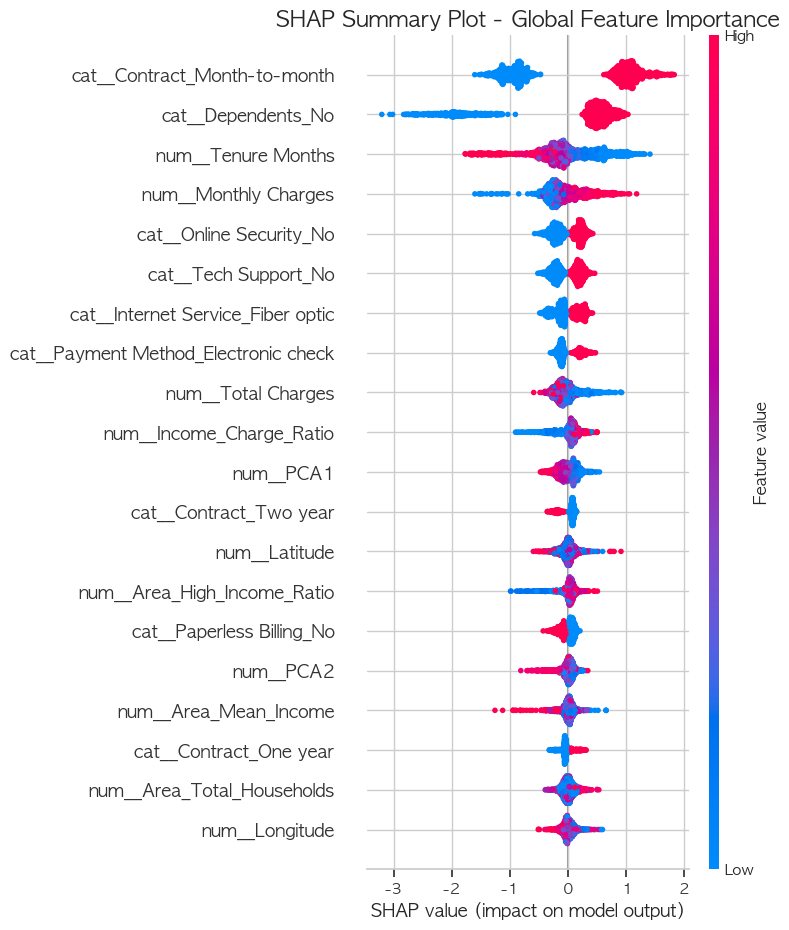

In [85]:
print("🔍 Performing SHAP analysis on the LightGBM model...")
lgbm_model = lgbm_pipeline.named_steps["classifier"]
preprocessor = lgbm_pipeline.named_steps["preprocessor"]

# Transform X_test to get the processed features
X_test_transformed = preprocessor.transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get feature names
try:
    feature_names = preprocessor.get_feature_names_out()
    X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)
except:
    X_test_shap = pd.DataFrame(X_test_transformed)

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_shap)

# Handle list output for binary classification models (LightGBM returns list)
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]  # Target class 1 (Churn)
else:
    shap_values_plot = shap_values

# Generate SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_plot, X_test_shap, show=False)
plt.title("SHAP Summary Plot - Global Feature Importance", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 6-2. SHAP Dependence Plots
Visualizing the interaction and non-linear effects of the dynamically selected top 3 features.

Top 3 Features: ['cat__Contract_Month-to-month', 'cat__Dependents_No', 'num__Tenure Months']


<Figure size 800x500 with 0 Axes>

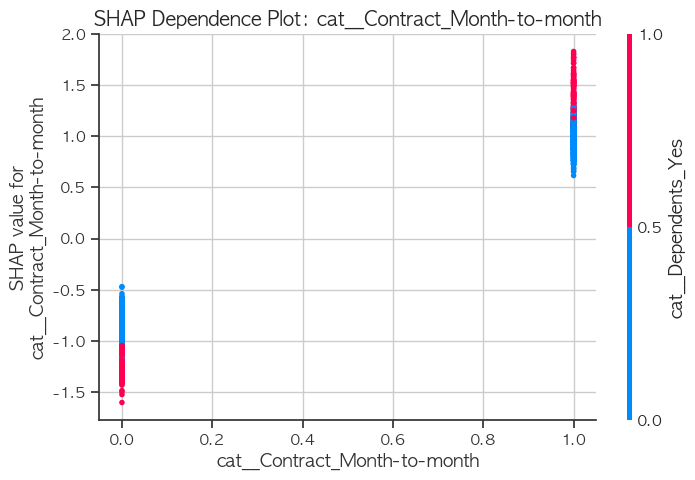

<Figure size 800x500 with 0 Axes>

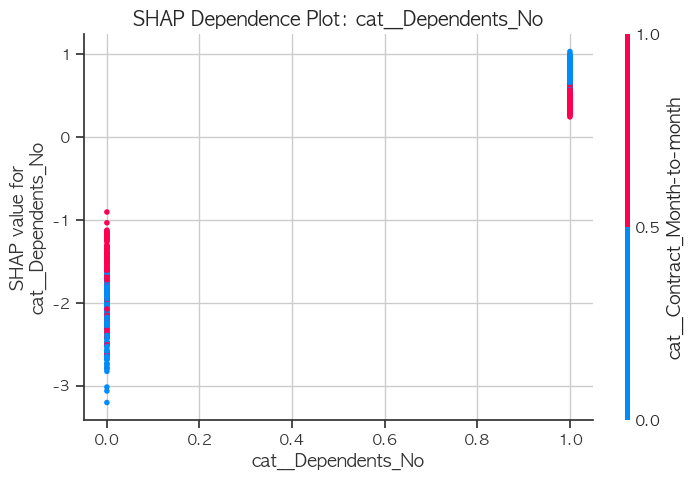

<Figure size 800x500 with 0 Axes>

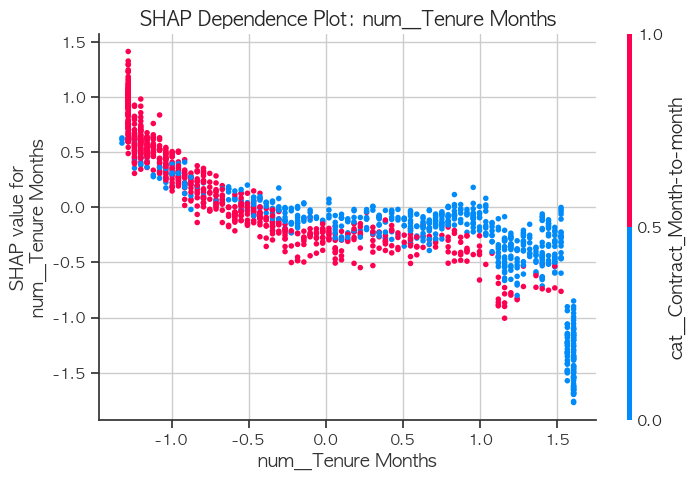

In [86]:
# Dynamically pick the top 3 features based on absolute mean SHAP values
mean_shap = np.abs(shap_values_plot).mean(axis=0)
top_indices = np.argsort(mean_shap)[-3:][::-1]
top_features = X_test_shap.columns[top_indices]

print("Top 3 Features:", list(top_features))

for feature in top_features:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        feature, 
        shap_values_plot, 
        X_test_shap, 
        interaction_index="auto", 
        show=False
    )
    plt.title(f"SHAP Dependence Plot: {feature}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 📊 Top 3 Key Churn Risk Factors

Based on the SHAP analysis above, the top 3 drivers of customer churn are:

1. **Contract Type (Month-to-Month)**: Customers not locked into an annual contract have significantly higher SHAP values, strongly driving churn probability upwards.
2. **Tenure Months (Early Lifecycle)**: Low tenure is a major risk factor. Customers in their first few months show a high propensity to leave.
3. **Income Segment & Monthly Charges**: Specific income segments, especially when interacting with high monthly charges, exhibit heightened churn sensitivity due to price burden.

---

## 💡 Data-Driven Retention Strategy

1. **Contract Conversion Incentives**: 
   - **Target**: Month-to-month customers with high churn risk.
   - **Action**: Offer a "Loyalty Upgrade" incentive (e.g., 10% monthly discount or a free streaming bundle for 3 months) if they switch to a 1-year or 2-year term contract.

2. **First 90-Day Onboarding Excellence**:
   - **Target**: New customers (Tenure < 3 months).
   - **Action**: Implement proactive engagement. Send personalized check-ins, offer premium technical support for the first 90 days, and ensure they are utilizing the features they signed up for to build early habituation.

3. **Income-Tailored Value Packages**:
   - **Target**: High-churn-risk customers in lower/middle-income segments facing high monthly charges.
   - **Action**: Proactively propose slightly downgraded, budget-friendly plans (e.g., DSL instead of Fiber) or flexible payment methods before they cancel, positioning it as a "Cost Optimization Consultation."

---

## 🚀 One-Line Summary Documentation (Demo Day Takeway)

> **"단기 계약 및 초기 가입자의 이탈 위험이 가장 높으며, 소득 구간별 맞춤형 약정 혜택과 결합 상품 제공이 리텐션의 핵심 방어선입니다."**